<a href="https://colab.research.google.com/github/PiyushGit11/Generative-AI-internship/blob/main/day5/assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [82]:
import pandas as pd

df = pd.read_csv('reviews_data.csv')

print(df.head())

       name           location                     Date  Rating  \
0     Helen  Wichita Falls, TX  Reviewed Sept. 13, 2023     5.0   
1  Courtney         Apopka, FL   Reviewed July 16, 2023     5.0   
2  Daynelle  Cranberry Twp, PA    Reviewed July 5, 2023     5.0   
3    Taylor        Seattle, WA    Reviewed May 26, 2023     5.0   
4   Tenessa        Gresham, OR   Reviewed Jan. 22, 2023     5.0   

                                              Review  \
0  Amber and LaDonna at the Starbucks on Southwes...   
1  ** at the Starbucks by the fire station on 436...   
2  I just wanted to go out of my way to recognize...   
3  Me and my friend were at Starbucks and my card...   
4  I’m on this kick of drinking 5 cups of warm wa...   

                                         Image_Links  
0                                      ['No Images']  
1                                      ['No Images']  
2  ['https://media.consumeraffairs.com/files/cach...  
3                                      [

In [83]:
df['Lowercase_Text'] = df['Review'].str.lower()

print(df[['Review', 'Lowercase_Text']].head())

                                              Review  \
0  Amber and LaDonna at the Starbucks on Southwes...   
1  ** at the Starbucks by the fire station on 436...   
2  I just wanted to go out of my way to recognize...   
3  Me and my friend were at Starbucks and my card...   
4  I’m on this kick of drinking 5 cups of warm wa...   

                                      Lowercase_Text  
0  amber and ladonna at the starbucks on southwes...  
1  ** at the starbucks by the fire station on 436...  
2  i just wanted to go out of my way to recognize...  
3  me and my friend were at starbucks and my card...  
4  i’m on this kick of drinking 5 cups of warm wa...  


In [84]:
import nltk
from nltk.tokenize import word_tokenize

nltk.download('punkt_tab')

df['Tokens'] = df['Review'].apply(word_tokenize)

for i in range(5):
    print(f"Sample {i+1}:")
    print(df['Tokens'].iloc[i])
    print("-" * 30)

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


Sample 1:
['Amber', 'and', 'LaDonna', 'at', 'the', 'Starbucks', 'on', 'Southwest', 'Parkway', 'are', 'always', 'so', 'warm', 'and', 'welcoming', '.', 'There', 'is', 'always', 'a', 'smile', 'in', 'their', 'voice', 'when', 'they', 'greet', 'you', 'at', 'the', 'drive-thru', '.', 'And', 'their', 'customer', 'service', 'is', 'always', 'spot-on', ',', 'they', 'always', 'get', 'my', 'order', 'right', 'and', 'with', 'a', 'smile', '.', 'I', 'would', 'actually', 'give', 'them', 'more', 'than', '5', 'stars', 'if', 'they', 'were', 'available', '.']
------------------------------
Sample 2:
['*', '*', 'at', 'the', 'Starbucks', 'by', 'the', 'fire', 'station', 'on', '436', 'in', 'Altamonte', 'Springs', ',', 'FL', 'made', 'my', 'day', 'and', 'finally', 'helped', 'me', 'figure', 'out', 'the', 'way', 'to', 'make', 'my', 'drink', 'so', 'I', '’', 'd', 'love', 'it', '.', 'She', 'took', 'time', 'out', 'to', 'talk', 'to', 'me', 'for', '2', 'minutes', 'to', 'make', 'my', 'experience', 'better', 'than', 'what',

In [85]:
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

df['Filtered_Tokens'] = df['Tokens'].apply(lambda tokens: [word for word in tokens if word.lower() not in stop_words and word.isalpha()])

for i in range(min(5, len(df))):
    print(f"Sample {i+1}:")
    print(f"Before (Tokens):         {df['Tokens'].iloc[i]}")
    print(f"After (Filtered Tokens): {df['Filtered_Tokens'].iloc[i]}")
    print("-" * 30)

Sample 1:
Before (Tokens):         ['Amber', 'and', 'LaDonna', 'at', 'the', 'Starbucks', 'on', 'Southwest', 'Parkway', 'are', 'always', 'so', 'warm', 'and', 'welcoming', '.', 'There', 'is', 'always', 'a', 'smile', 'in', 'their', 'voice', 'when', 'they', 'greet', 'you', 'at', 'the', 'drive-thru', '.', 'And', 'their', 'customer', 'service', 'is', 'always', 'spot-on', ',', 'they', 'always', 'get', 'my', 'order', 'right', 'and', 'with', 'a', 'smile', '.', 'I', 'would', 'actually', 'give', 'them', 'more', 'than', '5', 'stars', 'if', 'they', 'were', 'available', '.']
After (Filtered Tokens): ['Amber', 'LaDonna', 'Starbucks', 'Southwest', 'Parkway', 'always', 'warm', 'welcoming', 'always', 'smile', 'voice', 'greet', 'customer', 'service', 'always', 'always', 'get', 'order', 'right', 'smile', 'would', 'actually', 'give', 'stars', 'available']
------------------------------
Sample 2:
Before (Tokens):         ['*', '*', 'at', 'the', 'Starbucks', 'by', 'the', 'fire', 'station', 'on', '436', 'in',

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [86]:
from nltk.stem import PorterStemmer

stemmer = PorterStemmer()

df['Stemmed_Tokens'] = df['Filtered_Tokens'].apply(lambda tokens: [stemmer.stem(word) for word in tokens])

for i in range(min(10, len(df))):
    print(f"Sample {i+1}:")
    print(f"Before (Filtered Tokens): {df['Filtered_Tokens'].iloc[i]}")
    print(f"After (Stemmed Tokens):   {df['Stemmed_Tokens'].iloc[i]}")
    print("-" * 50)

Sample 1:
Before (Filtered Tokens): ['Amber', 'LaDonna', 'Starbucks', 'Southwest', 'Parkway', 'always', 'warm', 'welcoming', 'always', 'smile', 'voice', 'greet', 'customer', 'service', 'always', 'always', 'get', 'order', 'right', 'smile', 'would', 'actually', 'give', 'stars', 'available']
After (Stemmed Tokens):   ['amber', 'ladonna', 'starbuck', 'southwest', 'parkway', 'alway', 'warm', 'welcom', 'alway', 'smile', 'voic', 'greet', 'custom', 'servic', 'alway', 'alway', 'get', 'order', 'right', 'smile', 'would', 'actual', 'give', 'star', 'avail']
--------------------------------------------------
Sample 2:
Before (Filtered Tokens): ['Starbucks', 'fire', 'station', 'Altamonte', 'Springs', 'FL', 'made', 'day', 'finally', 'helped', 'figure', 'way', 'make', 'drink', 'love', 'took', 'time', 'talk', 'minutes', 'make', 'experience', 'better', 'used', 'much', 'appreciated', 'bad', 'experiences', 'one', 'another', 'Starbucks', 'closest', 'work', 'building', 'drinks', 'great', 'along', 'great', 'c

In [87]:
from nltk.stem import WordNetLemmatizer

nltk.download('wordnet')

lemmatizer = WordNetLemmatizer()

df['Lemmatized_Tokens'] = df['Filtered_Tokens'].apply(lambda tokens: [lemmatizer.lemmatize(word) for word in tokens])

for i in range(min(10, len(df))):
    print(f"Sample {i+1}:")
    print(f"Stemmed:   {df['Stemmed_Tokens'].iloc[i]}")
    print(f"Lemmatized: {df['Lemmatized_Tokens'].iloc[i]}")
    print("-" * 50)

Sample 1:
Stemmed:   ['amber', 'ladonna', 'starbuck', 'southwest', 'parkway', 'alway', 'warm', 'welcom', 'alway', 'smile', 'voic', 'greet', 'custom', 'servic', 'alway', 'alway', 'get', 'order', 'right', 'smile', 'would', 'actual', 'give', 'star', 'avail']
Lemmatized: ['Amber', 'LaDonna', 'Starbucks', 'Southwest', 'Parkway', 'always', 'warm', 'welcoming', 'always', 'smile', 'voice', 'greet', 'customer', 'service', 'always', 'always', 'get', 'order', 'right', 'smile', 'would', 'actually', 'give', 'star', 'available']
--------------------------------------------------
Sample 2:
Stemmed:   ['starbuck', 'fire', 'station', 'altamont', 'spring', 'fl', 'made', 'day', 'final', 'help', 'figur', 'way', 'make', 'drink', 'love', 'took', 'time', 'talk', 'minut', 'make', 'experi', 'better', 'use', 'much', 'appreci', 'bad', 'experi', 'one', 'anoth', 'starbuck', 'closest', 'work', 'build', 'drink', 'great', 'along', 'great', 'custom', 'servic', 'specif', 'barista', 'niko', 'refresh', 'speak', 'pleasant

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [88]:
from sklearn.feature_extraction.text import CountVectorizer

df['Filtered_Text'] = df['Filtered_Tokens'].apply(lambda x: ' '.join(x))

vectorizer = CountVectorizer()
bow_matrix = vectorizer.fit_transform(df['Filtered_Text'])

print("Vocabulary (Feature mapping):")
print(vectorizer.vocabulary_)

print("\nFeature Names (List of words):")
print(vectorizer.get_feature_names_out())

print("\nBoW Matrix (First 5 rows):\n")
print(bow_matrix.toarray()[:5])

print("\nShape of the Matrix:")
print(bow_matrix.shape)

Vocabulary (Feature mapping):
{'amber': 156, 'ladonna': 2614, 'starbucks': 4568, 'southwest': 4487, 'parkway': 3384, 'always': 152, 'warm': 5296, 'welcoming': 5348, 'smile': 4415, 'voice': 5255, 'greet': 2078, 'customer': 1158, 'service': 4252, 'get': 2003, 'order': 3289, 'right': 4022, 'would': 5444, 'actually': 60, 'give': 2014, 'stars': 4572, 'available': 314, 'fire': 1814, 'station': 4585, 'altamonte': 147, 'springs': 4547, 'fl': 1831, 'made': 2821, 'day': 1189, 'finally': 1803, 'helped': 2210, 'figure': 1790, 'way': 5322, 'make': 2834, 'drink': 1442, 'love': 2788, 'took': 4927, 'time': 4894, 'talk': 4780, 'minutes': 2984, 'experience': 1676, 'better': 441, 'used': 5155, 'much': 3067, 'appreciated': 222, 'bad': 343, 'experiences': 1678, 'one': 3264, 'another': 184, 'closest': 873, 'work': 5425, 'building': 600, 'drinks': 1447, 'great': 2069, 'along': 142, 'specific': 4508, 'baristas': 374, 'niko': 3155, 'refreshing': 3854, 'speak': 4500, 'pleasant': 3527, 'perfect': 3440, 'store': 

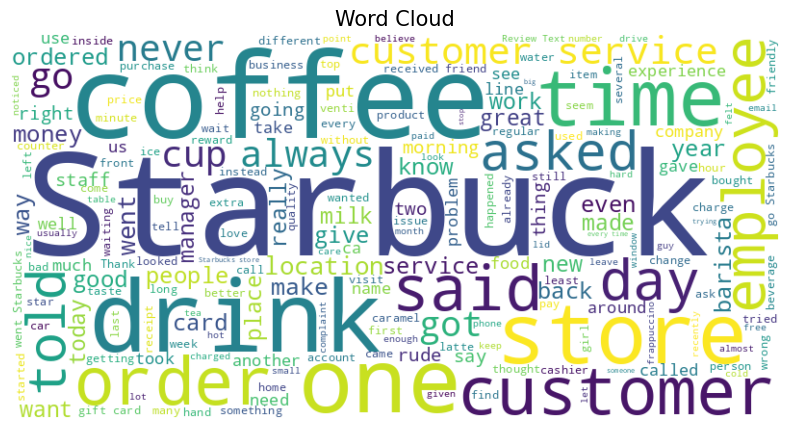

In [89]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt


text_data = " ".join(df['Filtered_Text'])

wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text_data)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud', fontsize=15)
plt.show()